In [1]:
import re
from urllib.parse import urljoin

import matplotlib.pyplot as plt
import pandas as pd
import requests
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

## everef Market History File Update Exploration

Quick notebook to see how the market history files are updated relative to their market_date. Docs mention they are updated in place, so this is useful to see how frequently files are updated, and when their final update occurs.

In [2]:
BASE_URL = "https://data.everef.net/market-history/"

YEAR_RE = re.compile(r"^\d{4}/?$")
FILE_RE = re.compile(r"market-history-(\d{4}-\d{2}-\d{2})\.csv\.bz2$")
LAST_MODIFIED_RE = re.compile(r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}) UTC")

session = requests.Session()
session.headers.update({
    "User-Agent": "eve-market-history-lag-analysis/0.1"
})

In [3]:
resp = session.get(BASE_URL, timeout=30)
resp.raise_for_status()

soup = BeautifulSoup(resp.text, "html.parser")

year_urls = []

for a in soup.find_all("a", href=True):
    href = a["href"]
    text = a.get_text(strip=True)

    if YEAR_RE.match(href) or YEAR_RE.match(text):
        year_urls.append(urljoin(BASE_URL, href))

year_urls = sorted(set(year_urls))

year_urls[:5], year_urls[-5:], len(year_urls)

(['https://data.everef.net/market-history/2003/',
  'https://data.everef.net/market-history/2004/',
  'https://data.everef.net/market-history/2005/',
  'https://data.everef.net/market-history/2006/',
  'https://data.everef.net/market-history/2007/'],
 ['https://data.everef.net/market-history/2022/',
  'https://data.everef.net/market-history/2023/',
  'https://data.everef.net/market-history/2024/',
  'https://data.everef.net/market-history/2025/',
  'https://data.everef.net/market-history/2026/'],
 24)

In [4]:
test_year_url = year_urls[-1]
test_year_url

'https://data.everef.net/market-history/2026/'

In [5]:
resp = session.get(test_year_url, timeout=30)
resp.raise_for_status()

soup = BeautifulSoup(resp.text, "html.parser")

rows = []

for a in soup.find_all("a", href=True):
    href = a["href"]
    filename = href.rstrip("/").split("/")[-1]

    file_match = FILE_RE.match(filename)
    if not file_match:
        continue

    # Usually the useful metadata is in the parent table row.
    parent = a.find_parent("tr") or a.parent
    row_text = parent.get_text(" ", strip=True) if parent else a.get_text(" ", strip=True)

    modified_match = LAST_MODIFIED_RE.search(row_text)
    if not modified_match:
        print("Could not parse:", filename, row_text)
        continue

    market_date = file_match.group(1)
    modified_at = modified_match.group(1)

    rows.append({
        "market_date": market_date,
        "modified_at": modified_at,
        "filename": filename,
        "url": urljoin(test_year_url, href),
        "raw_text": row_text,
    })

test_df = pd.DataFrame(rows)
test_df.head()

,market_date,modified_at,filename,url,raw_text
0,2026-01-01,2026-05-08 22:18:15,market-history-2026-01-01.csv.bz2,https://data.everef.net/market-history/2026/ma...,market-history-2026-01-01.csv.bz2 637.55 KiB 6...
1,2026-01-02,2026-05-17 19:20:25,market-history-2026-01-02.csv.bz2,https://data.everef.net/market-history/2026/ma...,market-history-2026-01-02.csv.bz2 653.60 KiB 6...
2,2026-01-03,2026-05-17 20:59:54,market-history-2026-01-03.csv.bz2,https://data.everef.net/market-history/2026/ma...,market-history-2026-01-03.csv.bz2 674.78 KiB 6...
3,2026-01-04,2026-05-11 17:28:12,market-history-2026-01-04.csv.bz2,https://data.everef.net/market-history/2026/ma...,market-history-2026-01-04.csv.bz2 665.11 KiB 6...
4,2026-01-05,2026-05-17 17:14:53,market-history-2026-01-05.csv.bz2,https://data.everef.net/market-history/2026/ma...,market-history-2026-01-05.csv.bz2 616.44 KiB 6...


In [6]:
all_rows = []

for year_url in tqdm(year_urls):
    resp = session.get(year_url, timeout=30)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")

    for a in soup.find_all("a", href=True):
        href = a["href"]
        filename = href.rstrip("/").split("/")[-1]

        file_match = FILE_RE.match(filename)
        if not file_match:
            continue

        parent = a.find_parent("tr") or a.parent
        row_text = parent.get_text(" ", strip=True) if parent else a.get_text(" ", strip=True)

        modified_match = LAST_MODIFIED_RE.search(row_text)
        if not modified_match:
            print("Could not parse:", year_url, filename, row_text)
            continue

        all_rows.append({
            "market_date": file_match.group(1),
            "modified_at": modified_match.group(1),
            "filename": filename,
            "url": urljoin(year_url, href),
        })

len(all_rows)

  0%|          | 0/24 [00:00<?, ?it/s]

8270

In [7]:
df = pd.DataFrame(all_rows)

df["market_date"] = pd.to_datetime(df["market_date"], utc=True)
df["modified_at"] = pd.to_datetime(df["modified_at"], utc=True)

df["lag_timedelta"] = df["modified_at"] - df["market_date"]
df["lag_days_exact"] = df["lag_timedelta"].dt.total_seconds() / 86_400
df["lag_days_floor"] = df["lag_days_exact"].astype(int)

df = df.sort_values("market_date").reset_index(drop=True)

df.head()

,market_date,modified_at,filename,url,lag_timedelta,lag_days_exact,lag_days_floor
0,2003-10-01 00:00:00+00:00,2018-03-09 00:00:00+00:00,market-history-2003-10-01.csv.bz2,https://data.everef.net/market-history/2003/ma...,5273 days,5273.0,5273
1,2003-10-02 00:00:00+00:00,2018-03-09 00:00:00+00:00,market-history-2003-10-02.csv.bz2,https://data.everef.net/market-history/2003/ma...,5272 days,5272.0,5272
2,2003-10-03 00:00:00+00:00,2018-03-09 00:00:00+00:00,market-history-2003-10-03.csv.bz2,https://data.everef.net/market-history/2003/ma...,5271 days,5271.0,5271
3,2003-10-04 00:00:00+00:00,2018-03-09 00:00:00+00:00,market-history-2003-10-04.csv.bz2,https://data.everef.net/market-history/2003/ma...,5270 days,5270.0,5270
4,2003-10-05 00:00:00+00:00,2018-03-09 00:00:00+00:00,market-history-2003-10-05.csv.bz2,https://data.everef.net/market-history/2003/ma...,5269 days,5269.0,5269


In [8]:
df.tail()

,market_date,modified_at,filename,url,lag_timedelta,lag_days_exact,lag_days_floor
8265,2026-05-20 00:00:00+00:00,2026-05-24 00:24:48+00:00,market-history-2026-05-20.csv.bz2,https://data.everef.net/market-history/2026/ma...,4 days 00:24:48,4.017222,4
8266,2026-05-21 00:00:00+00:00,2026-05-24 00:24:48+00:00,market-history-2026-05-21.csv.bz2,https://data.everef.net/market-history/2026/ma...,3 days 00:24:48,3.017222,3
8267,2026-05-22 00:00:00+00:00,2026-05-24 00:24:48+00:00,market-history-2026-05-22.csv.bz2,https://data.everef.net/market-history/2026/ma...,2 days 00:24:48,2.017222,2
8268,2026-05-23 00:00:00+00:00,2026-05-25 01:53:18+00:00,market-history-2026-05-23.csv.bz2,https://data.everef.net/market-history/2026/ma...,2 days 01:53:18,2.078681,2
8269,2026-05-24 00:00:00+00:00,2026-05-25 14:32:28+00:00,market-history-2026-05-24.csv.bz2,https://data.everef.net/market-history/2026/ma...,1 days 14:32:28,1.605880,1


In [9]:
df[["market_date", "modified_at", "lag_days_exact", "url"]].sample(10)

,market_date,modified_at,lag_days_exact,url
7303,2023-10-01 00:00:00+00:00,2024-03-17 22:30:58+00:00,168.938171,https://data.everef.net/market-history/2023/ma...
5617,2019-02-18 00:00:00+00:00,2019-04-17 05:54:44+00:00,58.246343,https://data.everef.net/market-history/2019/ma...
3415,2013-02-07 00:00:00+00:00,2018-03-09 00:00:00+00:00,1856.000000,https://data.everef.net/market-history/2013/ma...
7818,2025-02-27 00:00:00+00:00,2025-06-22 06:15:50+00:00,115.260995,https://data.everef.net/market-history/2025/ma...
2274,2009-12-24 00:00:00+00:00,2018-03-09 00:00:00+00:00,2997.000000,https://data.everef.net/market-history/2009/ma...
3941,2014-07-18 00:00:00+00:00,2018-03-09 00:00:00+00:00,1330.000000,https://data.everef.net/market-history/2014/ma...
6252,2020-11-14 00:00:00+00:00,2021-06-18 18:16:35+00:00,216.761516,https://data.everef.net/market-history/2020/ma...
6494,2021-07-14 00:00:00+00:00,2021-07-15 12:22:22+00:00,1.515532,https://data.everef.net/market-history/2021/ma...
7720,2024-11-21 00:00:00+00:00,2025-02-11 09:45:27+00:00,82.406563,https://data.everef.net/market-history/2024/ma...
3392,2013-01-15 00:00:00+00:00,2018-03-09 00:00:00+00:00,1879.000000,https://data.everef.net/market-history/2013/ma...


In [10]:
df["lag_days_exact"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    8270.000000
mean     1743.231368
std      1698.905798
min         1.076968
50%      1136.500000
75%      3203.750000
90%      4446.100000
95%      4859.550000
99%      5190.310000
max      5273.000000
Name: lag_days_exact, dtype: float64

In [11]:
df.sort_values("lag_days_exact", ascending=False).head(20)[
    ["market_date", "modified_at", "lag_days_exact", "url"]
]

,market_date,modified_at,lag_days_exact,url
0,2003-10-01 00:00:00+00:00,2018-03-09 00:00:00+00:00,5273.0,https://data.everef.net/market-history/2003/ma...
1,2003-10-02 00:00:00+00:00,2018-03-09 00:00:00+00:00,5272.0,https://data.everef.net/market-history/2003/ma...
2,2003-10-03 00:00:00+00:00,2018-03-09 00:00:00+00:00,5271.0,https://data.everef.net/market-history/2003/ma...
3,2003-10-04 00:00:00+00:00,2018-03-09 00:00:00+00:00,5270.0,https://data.everef.net/market-history/2003/ma...
4,2003-10-05 00:00:00+00:00,2018-03-09 00:00:00+00:00,5269.0,https://data.everef.net/market-history/2003/ma...
5,2003-10-06 00:00:00+00:00,2018-03-09 00:00:00+00:00,5268.0,https://data.everef.net/market-history/2003/ma...
6,2003-10-07 00:00:00+00:00,2018-03-09 00:00:00+00:00,5267.0,https://data.everef.net/market-history/2003/ma...
7,2003-10-08 00:00:00+00:00,2018-03-09 00:00:00+00:00,5266.0,https://data.everef.net/market-history/2003/ma...
8,2003-10-09 00:00:00+00:00,2018-03-09 00:00:00+00:00,5265.0,https://data.everef.net/market-history/2003/ma...
9,2003-10-10 00:00:00+00:00,2018-03-09 00:00:00+00:00,5264.0,https://data.everef.net/market-history/2003/ma...


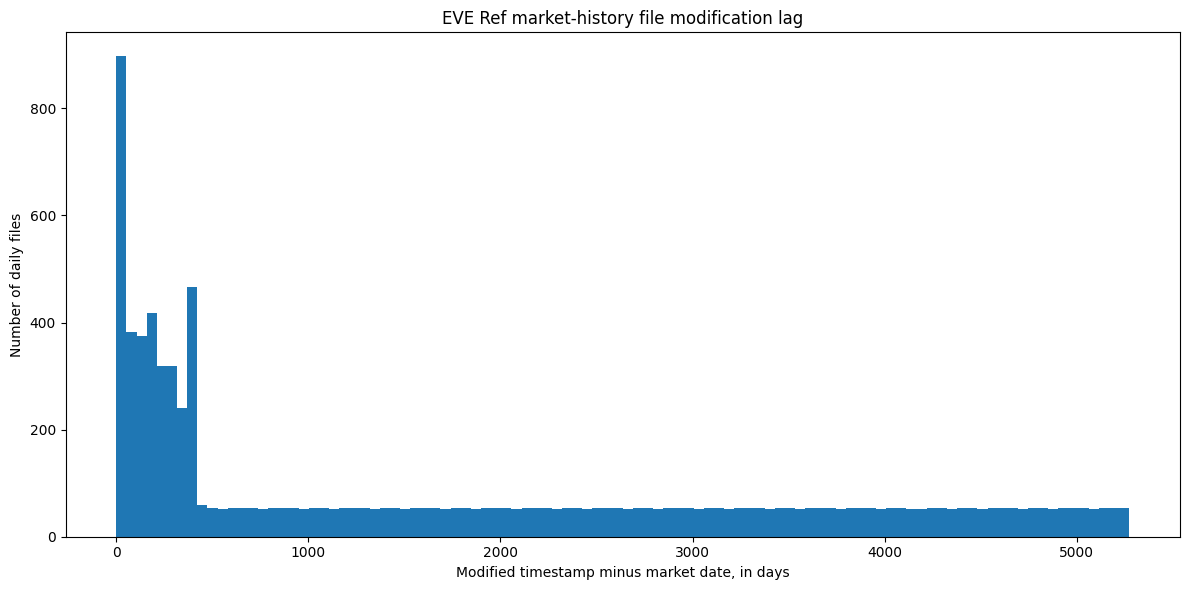

In [12]:
plt.figure(figsize=(12, 6))

plt.hist(df["lag_days_exact"], bins=100)

plt.title("EVE Ref market-history file modification lag")
plt.xlabel("Modified timestamp minus market date, in days")
plt.ylabel("Number of daily files")

plt.tight_layout()
plt.show()

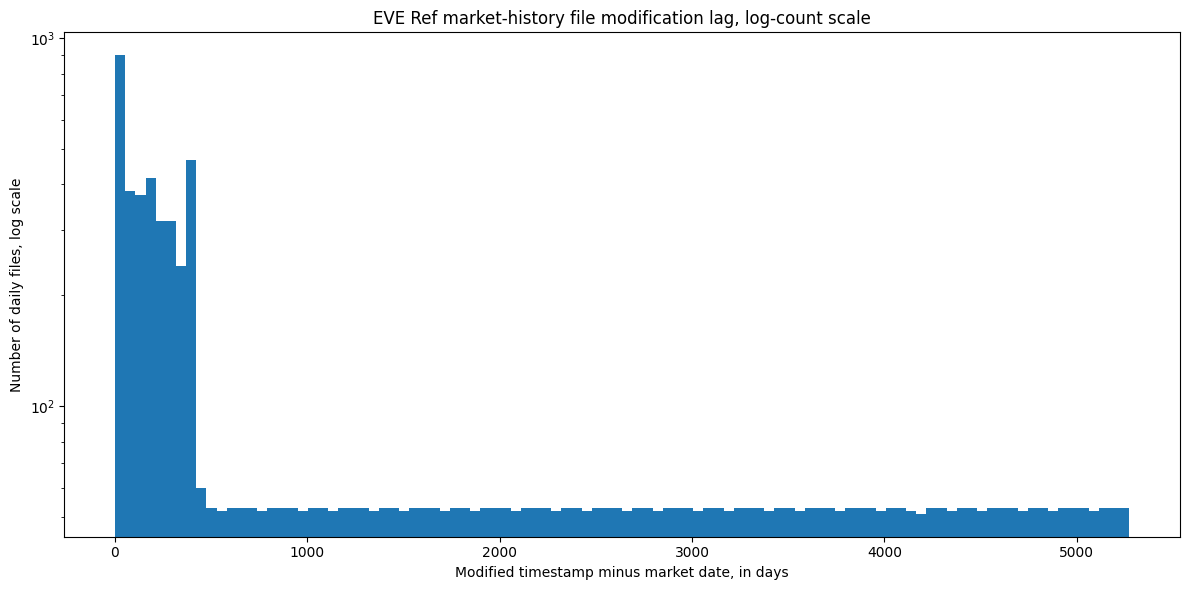

In [13]:
plt.figure(figsize=(12, 6))

plt.hist(df["lag_days_exact"], bins=100)
plt.yscale("log")

plt.title("EVE Ref market-history file modification lag, log-count scale")
plt.xlabel("Modified timestamp minus market date, in days")
plt.ylabel("Number of daily files, log scale")

plt.tight_layout()
plt.show()

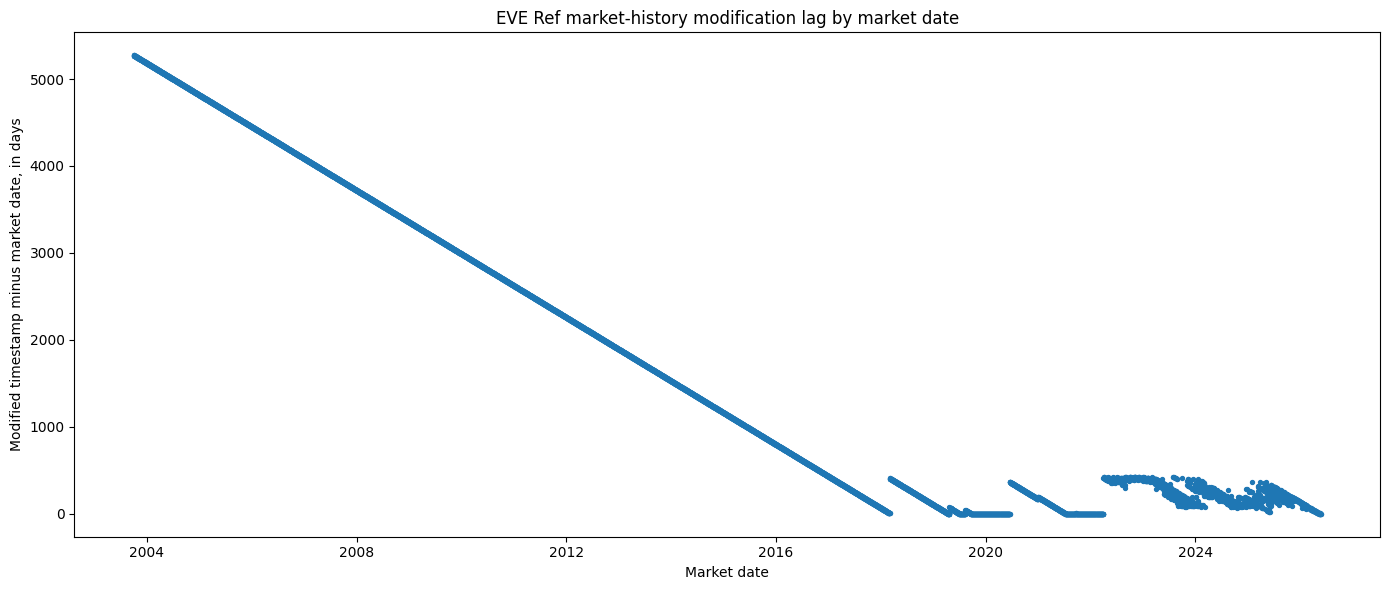

In [14]:
plt.figure(figsize=(14, 6))

plt.scatter(df["market_date"], df["lag_days_exact"], s=8)

plt.title("EVE Ref market-history modification lag by market date")
plt.xlabel("Market date")
plt.ylabel("Modified timestamp minus market date, in days")

plt.tight_layout()
plt.show()

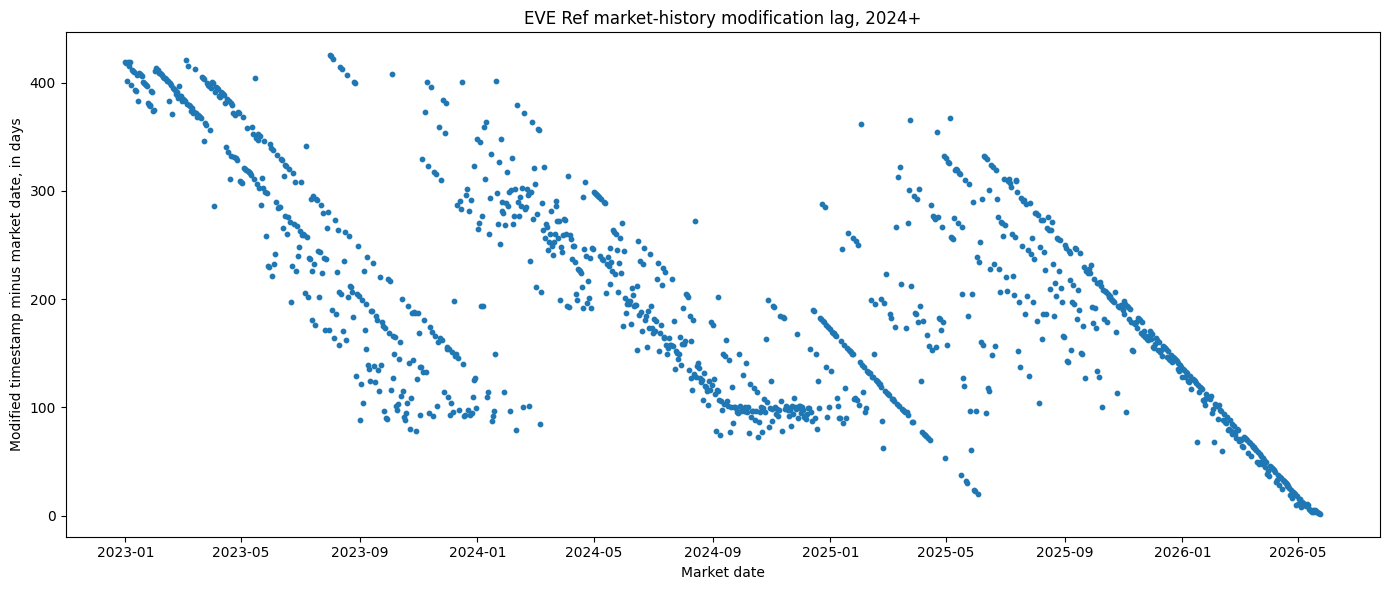

In [16]:
recent_df = df[df["market_date"] >= "2023-01-01"].copy()

plt.figure(figsize=(14, 6))

plt.scatter(recent_df["market_date"], recent_df["lag_days_exact"], s=10)

plt.title("EVE Ref market-history modification lag, 2024+")
plt.xlabel("Market date")
plt.ylabel("Modified timestamp minus market date, in days")

plt.tight_layout()
plt.show()